# 03 — From Time to Space + Time: The 1D Heat Equation (a PDE)

So far our unknown depended on **time only**: $y(t)$, $x(t)$. Real energy systems usually vary in **space
*and* time**: the temperature inside a pipe wall, a battery cell, an insulation layer, or a heat-storage tank
is a field $u(x, t)$ — different at every position *and* every instant.

Equations relating derivatives in **several variables** are called **Partial Differential Equations (PDEs)**.
The most important one for thermal energy is the **heat (diffusion) equation**. This notebook solves it with a
PINN. New ideas:

1. A network with **two inputs** $(x, t)$.
2. **Boundary conditions** (fixed temperatures at the ends) *and* an **initial condition** (starting temperature profile).
3. Sampling collocation points over a **2D domain**, and visualising the result as a **heat map**.

## 1. The heat equation and what it means physically

$$\frac{\partial u}{\partial t} \;=\; \alpha\,\frac{\partial^2 u}{\partial x^2}$$

Read it in plain words: *the temperature at a point rises or falls in proportion to how "curved" the
temperature profile is around it.* A local hot spot (a bump, negative curvature) cools; a local dip fills in.
Heat flows from hot to cold and smooths everything out over time.

- $u(x,t)$ = temperature at position $x$, time $t$.
- $\alpha$ = **thermal diffusivity** [m²/s]: how fast heat spreads. Big $\alpha$ (copper) → fast; small
  $\alpha$ (insulation, rock) → slow. *Remember $\alpha$ — in notebook 04 we will pretend we don't know it and
  make the PINN discover it from sensors.*

**Important**: As the equation it is 2nd order on X and 1st order on t, it will need two conditions on X (called boundary conditions, normally applied on the extremes)
and 1 condition on t (called initial condition, normally applied on t=0). Also it is important to remember that the conditions could be
of:

- 0 order, like u(xi, ti) = Ki (Dirichlet)
- 1st order, like u'(xj, tj) = Kj (Neuman).

**Our specific setup** (a rod of length $L=1$, insulated sides, ends held at 0):

- Domain: $x\in[0,1]$, $t\in[0,1]$.
- **1 Initial condition (IC):** $u(x,0)=\sin(\pi x)$ — a warm bump in the middle at the start.
- **2 Boundary conditions (BC):** $u(0,t)=u(1,t)=0$ — both ends clamped to zero temperature (e.g. touching a cold reservoir).

This one has a known exact solution to grade against: $\;u(x,t)=\sin(\pi x)\,e^{-\alpha \pi^2 t}$ — the bump
keeps its shape but **decays** exponentially in time.

In [1]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

torch.manual_seed(0); np.random.seed(0)
device = torch.device("cpu")

alpha = 0.1     # thermal diffusivity
L, T = 1.0, 1.0

def exact(x, t):
    return np.sin(np.pi*x) * np.exp(-alpha*np.pi**2*t)

## 2. The domain and the three kinds of points (schematic)

For a PDE we enforce the equation and the conditions at different places in the $(x,t)$ rectangle:

- **Interior / collocation points** (blue): the PDE $u_t=\alpha u_{xx}$ must hold here.
- **Initial-condition points** (green) along the bottom edge $t=0$: here $u=\sin(\pi x)$.
- **Boundary-condition points** (red) along the left/right edges $x=0$ and $x=1$: here $u=0$.

The picture below is worth memorising — it is the same layout for *almost every* forward PINN.

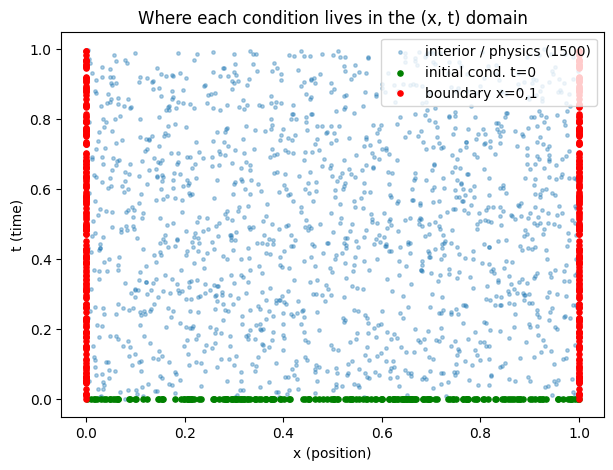

In [ ]:
# sample the three point sets
N_f  = 1500     # interior (physics) points
N_ic = 200      # initial-condition points
N_bc = 200      # boundary-condition points per side

x_f = torch.rand(N_f, 1)*L
t_f = torch.rand(N_f, 1)*T

x_ic = torch.rand(N_ic, 1)*L
t_ic = torch.zeros(N_ic, 1)

t_bc = torch.rand(N_bc, 1)*T
x_bc0 = torch.zeros(N_bc, 1)     # left edge x=0
x_bcL = torch.ones(N_bc, 1)*L    # right edge x=L

plt.figure(figsize=(7,5))
plt.scatter(x_f.numpy(), t_f.numpy(), s=6, alpha=0.35, label=f"interior / physics ({N_f})")
plt.scatter(x_ic.numpy(), t_ic.numpy(), s=14, color="green", label="initial cond. t=0")
plt.scatter(x_bc0.numpy(), t_bc.numpy(), s=14, color="red", label="boundary x=0,1")
plt.scatter(x_bcL.numpy(), t_bc.numpy(), s=14, color="red")
plt.xlabel("x (position)"); plt.ylabel("t (time)")
plt.title("Where each condition lives in the (x, t) domain"); plt.legend(loc="upper right"); plt.show()

# we add BC and IC points apart from the collocation points to ensure that the model learns the initial and boundary conditions well. 
# The collocation points are used to enforce the PDE in the interior of the domain.
# but we need for example to test the model at different times for position x=0 and x=L, 
# for that reason, we add boundary points at x=0 and x=L for different times t.

## 3. Network with two inputs, and the PDE residual

The network now maps $(x,t)\rightarrow u$, so the first layer has **2 inputs** and the last layer will have 
**1 input**. To build the residual we need $u_t$ (one derivative in $t$) and $u_{xx}$ (two derivatives in $x$). 
We keep `x` and `t` as *separate* tensors that each `require_grad`, concatenate them for the forward pass, and 
differentiate with respect to each.

In [ ]:
class MLP(nn.Module):
    def __init__(self, hidden=32, n_hidden_layers=4):
        super().__init__()
        layers = [nn.Linear(2, hidden), nn.Tanh()] # 1st hidden layer; 2 inputs: x and t
        for _ in range(n_hidden_layers - 1):
            layers += [nn.Linear(hidden, hidden), nn.Tanh()] # N-1 hidden layers
        layers += [nn.Linear(hidden, 1)] # output layer
        self.net = nn.Sequential(*layers)
    def forward(self, x, t):
        return self.net(torch.cat([x, t], dim=1))

model = MLP().to(device)

def pde_residual(x, t):
    x = x.requires_grad_(True); t = t.requires_grad_(True)
    u = model(x, t)
    u_t  = torch.autograd.grad(u,  t, torch.ones_like(u),  create_graph=True)[0]
    u_x  = torch.autograd.grad(u,  x, torch.ones_like(u),  create_graph=True)[0]
    u_xx = torch.autograd.grad(u_x, x, torch.ones_like(u_x), create_graph=True)[0]
    return u_t - alpha*u_xx     # = 0 when the heat equation holds

## 4. The loss — physics + initial + boundary

$$\mathcal{L} = \underbrace{\overline{r^2}}_{\text{PDE interior}}
\; +\; w_{ic}\,\underbrace{\overline{(u(x,0)-\sin\pi x)^2}}_{\text{initial}}
\; +\; w_{bc}\,\underbrace{\overline{(u(0,t))^2 + (u(1,t))^2}}_{\text{boundary}}$$

Same recipe as before, just one more condition type. We move the point tensors to the device and give the IC/BC
terms weights so they are not drowned out by the interior term.

In [ ]:
x_f, t_f = x_f.to(device), t_f.to(device)
x_ic, t_ic = x_ic.to(device), t_ic.to(device)
u_ic_true = torch.sin(np.pi*x_ic)                     # target initial profile
t_bc = t_bc.to(device); x_bc0 = x_bc0.to(device); x_bcL = x_bcL.to(device)

# w_ic and w_bc are weights for the initial condition and boundary condition loss, respectively.
# these weights are hyperparameters that can be tuned to balance the contributions of each loss term in the total loss function.
# we are given initial and bc more importance than the physics loss since they are more reliable and accurate, while the physics 
# loss is based on the model's predictions and may be less accurate.
w_ic, w_bc = 20.0, 20.0

def compute_loss():
    r = pde_residual(x_f, t_f)
    loss_pde = torch.mean(r**2)

    u_ic = model(x_ic, t_ic)
    loss_ic = torch.mean((u_ic - u_ic_true)**2)

    u_b0 = model(x_bc0, t_bc)
    u_bL = model(x_bcL, t_bc)
    loss_bc = torch.mean(u_b0**2) + torch.mean(u_bL**2)

    return loss_pde + w_ic*loss_ic + w_bc*loss_bc, loss_pde, loss_ic, loss_bc

## 5. Train

iter     0 | total 8.667e+00 | pde 1.524e-03 | ic 2.175e-01 | bc 2.158e-01
iter  1000 | total 6.204e-03 | pde 4.850e-03 | ic 5.444e-05 | bc 1.325e-05
iter  2000 | total 3.981e-03 | pde 2.305e-03 | ic 4.646e-05 | bc 3.735e-05
iter  3000 | total 1.344e-03 | pde 9.956e-04 | ic 8.949e-06 | bc 8.460e-06
iter  4000 | total 8.451e-04 | pde 6.339e-04 | ic 3.975e-06 | bc 6.588e-06
iter  5000 | total 6.632e-04 | pde 5.148e-04 | ic 2.026e-06 | bc 5.395e-06


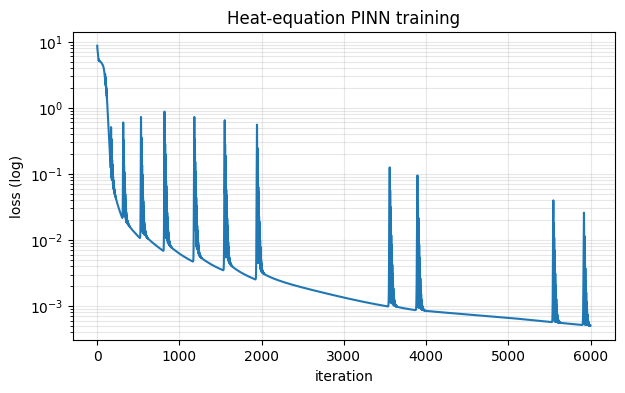

In [5]:
optimizer = torch.optim.Adam(model.parameters(), lr=2e-3)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=2000, gamma=0.5)

history = []
for it in range(6000):                    # ~2-3 min on CPU
    optimizer.zero_grad()
    loss, lp, lic, lbc = compute_loss()
    loss.backward(); optimizer.step(); scheduler.step()
    history.append(loss.item())
    if it % 1000 == 0:
        print(f"iter {it:5d} | total {loss.item():.3e} | pde {lp.item():.3e} | ic {lic.item():.3e} | bc {lbc.item():.3e}")

plt.figure(figsize=(7,4)); plt.semilogy(history)
plt.xlabel("iteration"); plt.ylabel("loss (log)"); plt.title("Heat-equation PINN training")
plt.grid(True, which="both", alpha=0.3); plt.show()

## 6. Visualise the solution field and compare with the exact one

We evaluate the trained PINN on a fine $(x,t)$ grid and draw three heat maps side by side: the PINN, the exact
solution, and their difference. Left-to-right they should look nearly identical, and the error map should be
close to flat.

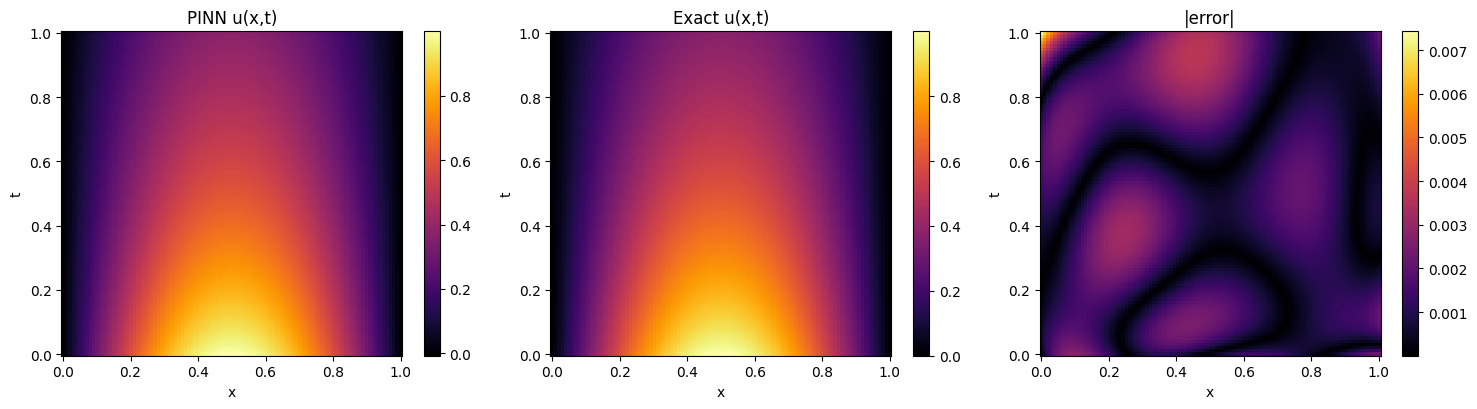

max abs error over grid: 0.007428660988807678


In [6]:
nx, nt = 100, 100
xs = np.linspace(0, L, nx); ts = np.linspace(0, T, nt)
Xg, Tg = np.meshgrid(xs, ts)
xt = np.stack([Xg.ravel(), Tg.ravel()], axis=1)
xx = torch.tensor(xt[:, :1], dtype=torch.float32, device=device)
tt = torch.tensor(xt[:, 1:], dtype=torch.float32, device=device)
with torch.no_grad():
    U_pinn = model(xx, tt).cpu().numpy().reshape(nt, nx)
U_exact = exact(Xg, Tg)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
for ax, data, title in zip(
    axes, [U_pinn, U_exact, np.abs(U_pinn-U_exact)],
    ["PINN u(x,t)", "Exact u(x,t)", "|error|"]):
    im = ax.pcolormesh(Xg, Tg, data, shading="auto", cmap="inferno")
    ax.set_xlabel("x"); ax.set_ylabel("t"); ax.set_title(title)
    fig.colorbar(im, ax=ax)
plt.tight_layout(); plt.show()

print("max abs error over grid:", np.max(np.abs(U_pinn - U_exact)))

## 7. Snapshots in time — watch the heat spread out

Heat maps are nice, but engineers often think in **temperature profiles at fixed times**. Here we slice the
field at a few instants. You should see the initial bump **flatten and shrink** as heat diffuses to the cold ends.

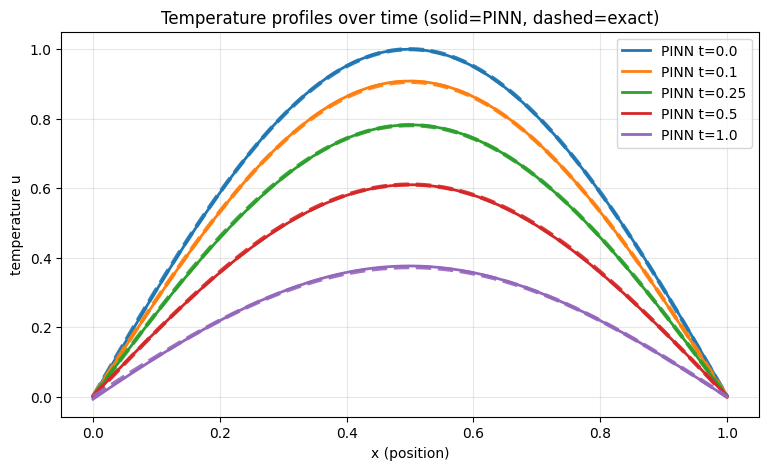

In [16]:
plt.figure(figsize=(9,5))
for t_snap in [0.0, 0.1, 0.25, 0.5, 1.0]:
    xline = torch.linspace(0, L, 200, device=device).reshape(-1,1)
    tline = torch.full_like(xline, t_snap)
    with torch.no_grad():
        u_line = model(xline, tline).cpu().numpy().flatten()
    xl = xline.cpu().numpy().flatten()
    p = plt.plot(xl, u_line, lw=2, label=f"PINN t={t_snap}")
    plt.plot(xl, exact(xl, t_snap), "--", color=p[0].get_color(), lw=3, alpha=0.9)
plt.xlabel("x (position)"); plt.ylabel("temperature u")
plt.title("Temperature profiles over time (solid=PINN, dashed=exact)")
plt.legend(); plt.grid(alpha=0.3); plt.show()

## 8. Why this matters for energy — and the honest trade-off

The heat equation (and its cousins) governs a huge slice of energy engineering: heat loss through **pipe and
tank insulation**, **battery** thermal management, **building** heating, **ground** heat exchangers, **thermal
storage**. A PINN gives you a *mesh-free*, *differentiable* surrogate of the temperature field.

But be fair about the trade-off for this **forward** problem: a classical solver (finite differences/elements)
would solve this textbook case faster and more reliably. **So why use a PINN at all?** The real payoff comes
when the classical approach struggles:

- you **don't know a parameter** (like $\alpha$) and must infer it from data → **notebook 04**,
- you have **scattered sensor measurements** to fuse with the physics,
- the geometry/data is irregular, or you want one **differentiable** model for optimisation and control.

That is the bridge to the business notebooks. **Forward PINNs teach the mechanics; inverse PINNs pay the bills.**

## 9. Recap

- A **PDE** couples derivatives in several variables; here temperature $u(x,t)$ in space *and* time.
- The PINN takes **two inputs**, and the loss now has **three** parts: interior PDE, initial condition, boundary conditions.
- We visualised the field as a **heat map** and as **time snapshots**, matching the exact solution.
- Forward PINNs are elegant but not always the fastest tool — their real edge is **inverse / data-fusion** problems.

**Next (04):** the first genuine business pattern — a **digital twin**. We hide $\alpha$, scatter a few noisy
temperature **sensors**, and let the PINN *discover the material property and reconstruct the full field* at once.